# NB2 — Baseline deployment study: a synthetic classifier with known latent outcomes

Part 1 of the walkthrough builds the deployed system and shows a naive
monitor's failure modes *before* any of the papers' instruments are applied.
The sequence is data understanding -> preprocessing -> training ->
post-training visualization -> metric observability. Trace slugs identify the
paper-grounded claims; everything else is `derived here`.

Traces: `nlm/responses/t5-monitoring-r1-q1.json` (setup and taxonomy),
`nlm/responses/t5-monitoring-r1-q2.json` (SJS), `nlm/responses/t5-monitoring-r1-q3.json`
(sequential test), `nlm/responses/t5-monitoring-r1-q4.json` (D3M).


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

_root = Path.cwd()
while not (_root / "exec" / "figures.py").is_file():
    if _root.parent == _root:
        raise RuntimeError("could not locate the project root from the working directory")
    _root = _root.parent
ROOT = _root
sys.path.insert(0, str(ROOT))

from exec import figures, run_study            # noqa: E402
from exec.synthetic import make_shift_scenario  # noqa: E402
from exec.estimators import (                    # noqa: E402
    estimate_sjs_gap,
    sequential_tail_monitor,
    d3m_disagreement_monitor,
)
from exec.controller import Controller, IllegalTransition  # noqa: E402
from exec.policy import compare_policies, compute_signals, run_stream, POLICY_NAMES  # noqa: E402

MANIFEST = run_study.ensure_figures()
RUN_ID = MANIFEST.get("run_id", "unknown")
print("study run:", RUN_ID)
print("figures ready:", sorted(MANIFEST.get("figures", {}).keys()))


def show_figure(stem):
    """Visualization-only cell: display the realized figure with its caption."""
    display(Markdown("**How to read this chart.** " + figures.CAPTIONS[stem]))
    display(Image(filename=str(ROOT / "exec" / "figures" / f"{stem}.png")))


study run: t5-r01-20260922T053253Z
figures ready: ['delayed-audit-timeline', 'fig-a1', 'fig-a2', 'fig-a3', 'fig-a4', 'fig-a5', 'fig-a6', 'fig-a7', 'fig-a8', 'fig-a8-bound', 'fig-a9', 'observable-invariance']


## 1. Data understanding

Six regimes share one source sample and one frozen champion. `latent_risk` is
the champion's Brier risk under the regime's target law; it is evaluation-only.


In [2]:

table = []
for regime in figures.REGIME_ORDER:
    s = make_shift_scenario(seed=101, regime=regime, n_source=2000, n_target=1400)
    table.append({"regime": regime, "champion_source_risk": round(s.source_risk, 4),
                  "latent_target_risk": round(s.target_risk, 4), "latent_gap": round(s.true_gap, 4),
                  "shift_features": str(s.shift_features)})
display(pd.DataFrame(table))


,regime,champion_source_risk,latent_target_risk,latent_gap,shift_features
0,none,0.0904,0.0904,0.0000,()
1,benign_covariate,0.0904,0.0905,0.0001,"(5, 6, 7)"
2,sparse_joint,0.0904,0.1425,0.0521,"(0, 1)"
3,harmful_concept,0.0904,0.2979,0.2075,"(0, 1)"
4,dense_joint,0.0904,0.0923,0.0019,"(0, 1, 2, 3, 4, 5, 6, 7)"
5,d3m_regime_2,0.2166,0.1869,-0.0296,"(0, 1)"


**How to read this chart.** How to read this chart: each row is one feature and the colour is its standardised deployment-minus-reference mean.
Read the second panel against the first: benign drift moves three noise features hard while latent risk stays put, and dense joint shift moves every feature while risk barely changes. Drift magnitude is not a retraining oracle.

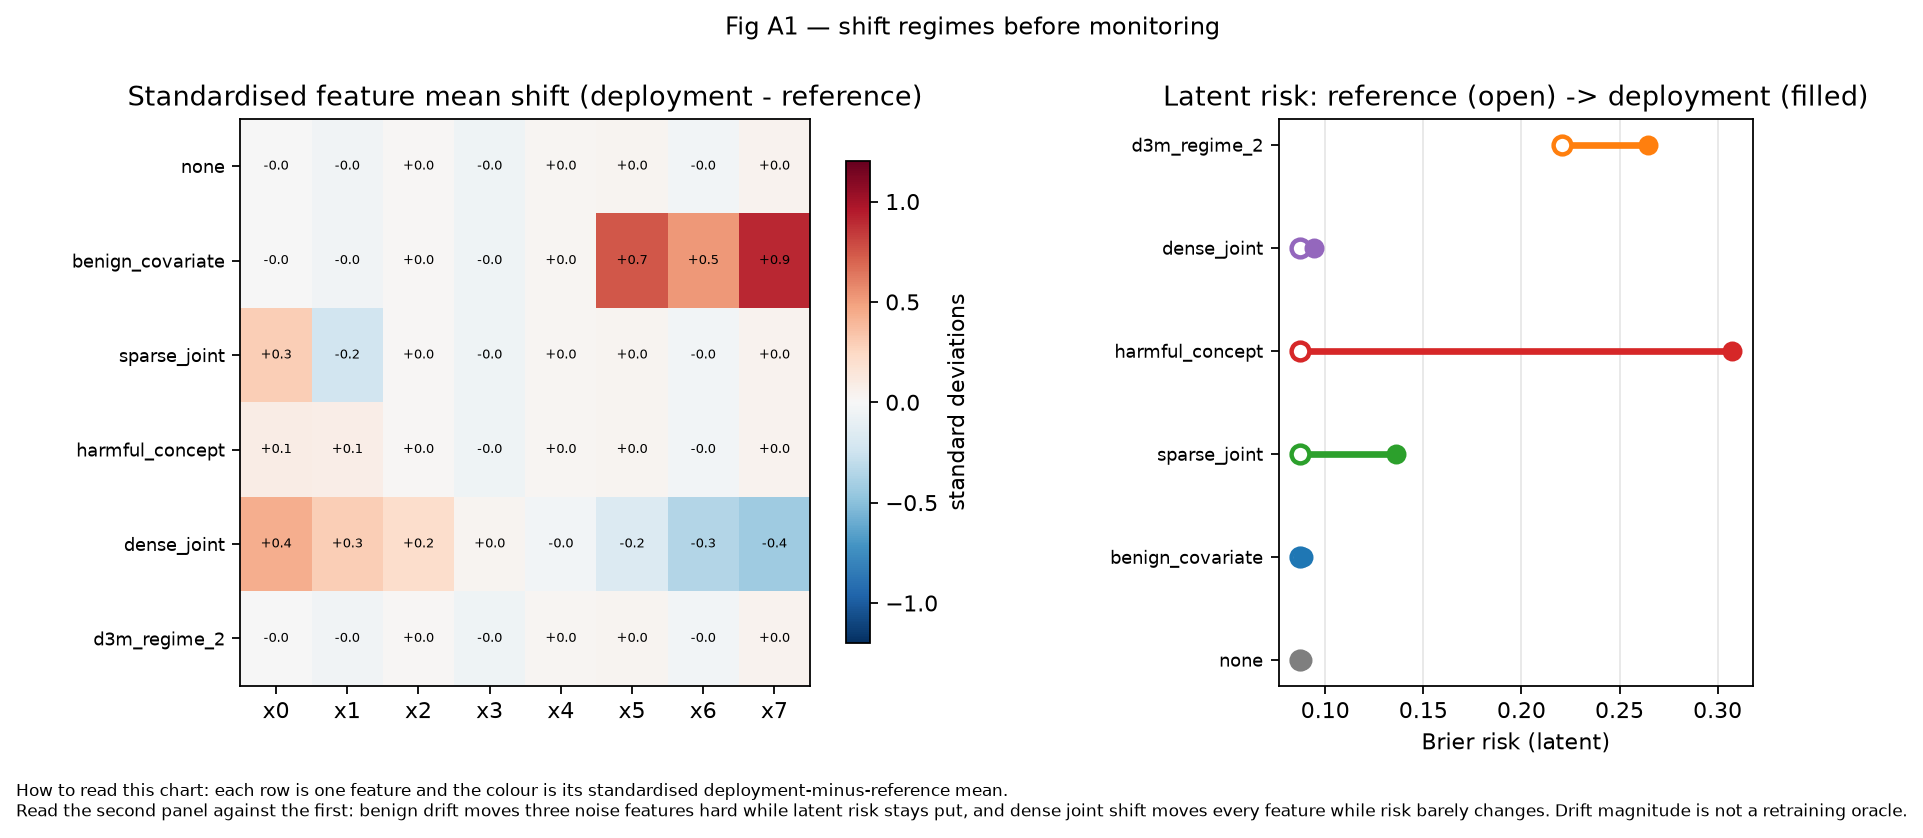

In [3]:
show_figure("fig-a1")

**Self-check 1.** Feature drift and latent risk must be ordered differently:
benign drift moves label-irrelevant features while risk is unchanged, and the
harmful regime changes risk while moving fewer features.


In [4]:

benign = make_shift_scenario(seed=101, regime="benign_covariate", n_source=2000, n_target=1400)
sparse = make_shift_scenario(seed=101, regime="sparse_joint", n_source=2000, n_target=1400)
harmful = make_shift_scenario(seed=101, regime="harmful_concept", n_source=2000, n_target=1400)
assert abs(benign.true_gap) < 0.02 < harmful.true_gap
assert len(benign.shift_features) >= len(harmful.shift_features)
print("self-check 1 PASS: benign gap", round(benign.true_gap, 4), "| sparse", round(sparse.true_gap, 4),
      "| harmful", round(harmful.true_gap, 4))


self-check 1 PASS: benign gap 0.0001 | sparse 0.0521 | harmful 0.2075


## 2. Preprocessing and training

The champion is logistic regression on 8 standardized-able Gaussian features;
the true label rule is a logistic boundary in x0 + x1 with 0.35-scale noise, so
the source risk sits near 0.09. Calibration data for error estimation is a
disjoint half of the source sample; the monitor never sees target labels.


In [5]:

from sklearn.linear_model import LogisticRegression
rng = np.random.default_rng(3)
s = make_shift_scenario(seed=101, regime="harmful_concept", n_source=2000, n_target=1400)
perm = rng.permutation(len(s.source_x))
cal_x, cal_y = s.source_x[perm[:800]], s.source_y[perm[:800]]
probe = LogisticRegression(max_iter=2000).fit(s.source_x[perm[800:]], s.source_y[perm[800:]])
print("calibration sample:", cal_x.shape, "| overlap with training:", len(set(perm[:800]) & set(perm[800:])))
print("champion-ish calibration risk:", float(np.mean((probe.predict_proba(cal_x)[:, 1] - cal_y) ** 2)))


calibration sample: (800, 8) | overlap with training: 0
champion-ish calibration risk: 0.09756411523505826


## 3. A naive monitor's failure modes

The naive monitor watches feature drift: the maximum standardised mean movement
over a rolling window. `drift_only` in `exec/policy.py` treats that statistic as
a retraining trigger.


In [6]:

from exec.policy import compute_signals
s = make_shift_scenario(seed=52, regime="benign_covariate", n_source=1800, n_target=1800)
stream = s.sample_deployment(seed=52)
sig = compute_signals(s, stream, seed=52)
post = slice(stream.onset_step + 4, None)
print("drift threshold:", round(sig.drift_threshold, 3))
print("mean drift statistic after onset:", float(np.mean(sig.drift[post])))
print("latent risk change (benign):", round(s.true_gap, 4))


drift threshold: 0.216
mean drift statistic after onset: 0.8774581249633137
latent risk change (benign): 0.0052


**Self-check 2.** On benign drift the drift statistic crosses the calibrated
threshold (the naive monitor fires) while the latent risk change stays near
zero — the C4 over-triggering case.


In [7]:

assert float(np.mean(sig.drift[post])) > sig.drift_threshold
assert abs(s.true_gap) < 0.02
print("self-check 2 PASS: drift fires (", round(float(np.mean(sig.drift[post])), 2), ">",
      round(sig.drift_threshold, 2), ") while latent gap is", round(s.true_gap, 4))


self-check 2 PASS: drift fires ( 0.88 > 0.22 ) while latent gap is 0.0052


**How to read this chart.** How to read this chart: the point is the estimated target-source gap, the bar is its 90% bootstrap interval, and the dashed vertical line is latent truth.
Filled markers are certified SJS estimates and open markers are refused diagnostics; a dense joint shift must appear as a refusal and a label-rule change must not be silently certified.

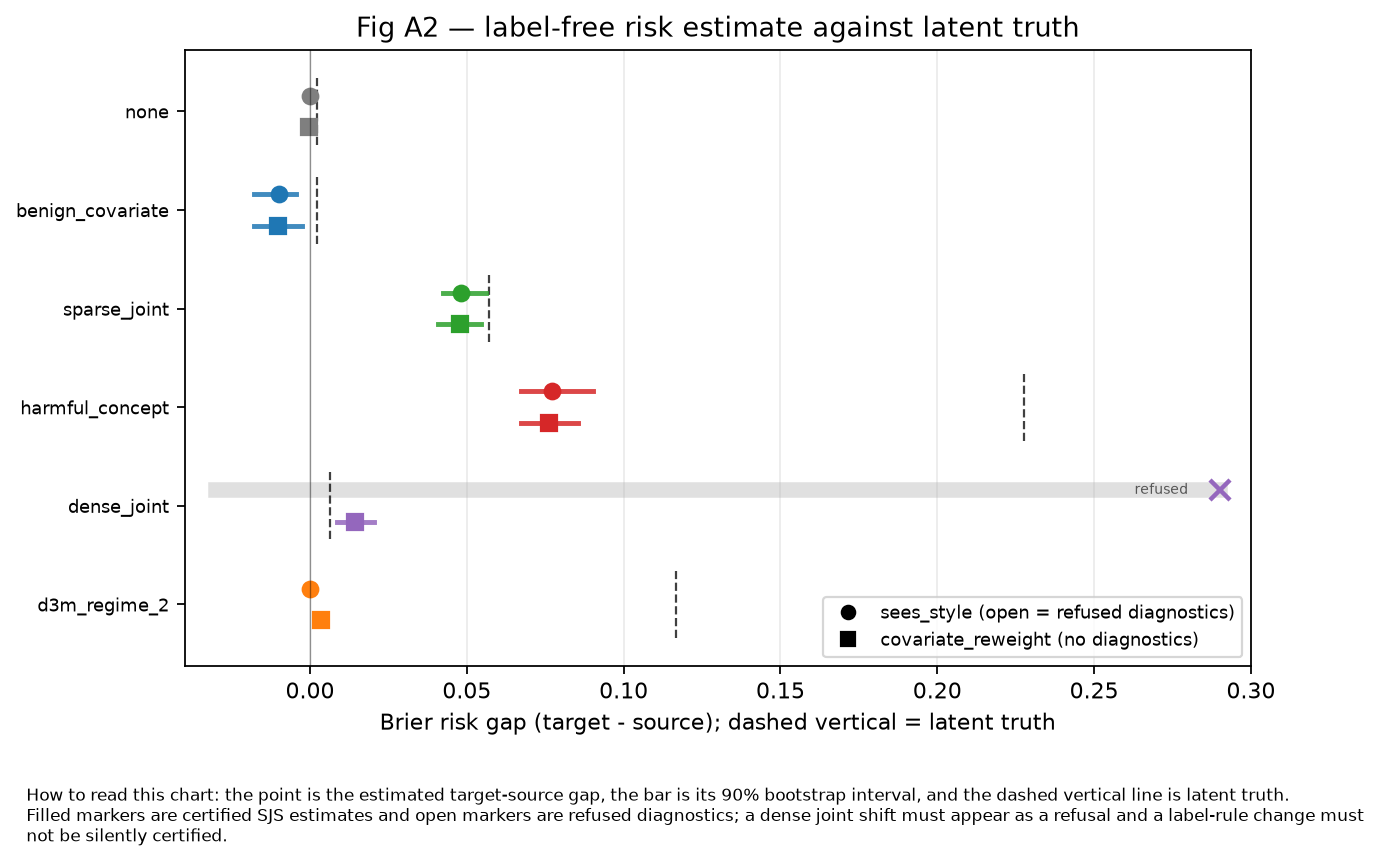

In [8]:
show_figure("fig-a2")

**Self-check 3.** The batch SJS estimate separates benign from harmful covariate
shifts, but under the label-rule change its point estimate stays far below
latent truth: the covariate explanation is incomplete. This is the identifiability
boundary, not a bug (trace `t5-monitoring-r1-q2`).


In [9]:

harm = make_shift_scenario(seed=11, regime="harmful_concept", n_source=2400, n_target=1800)
res_harm = estimate_sjs_gap(harm.source_x, harm.source_y, harm.target_x, harm.predictions)
base = make_shift_scenario(seed=11, regime="benign_covariate", n_source=2400, n_target=1800)
res_base = estimate_sjs_gap(base.source_x, base.source_y, base.target_x, base.predictions)
assert res_harm.estimate < 0.5 * harm.true_gap
assert abs(res_base.estimate) < 0.05
print("self-check 3 PASS: concept-shift estimate", round(res_harm.estimate, 3),
      "vs latent", round(harm.true_gap, 3), "| benign estimate", round(res_base.estimate, 3))


self-check 3 PASS: concept-shift estimate 0.078 vs latent 0.236 | benign estimate -0.009


## 4. Post-training visualization: are alarms time-uniform?

The sequential monitor of P2 (trace `t5-monitoring-r1-q3`) is calibrated on the
source sample and run over no-harm and harmful streams. Under the no-harm law
the lower bound must stay under the source rate plus tolerance; under harm the
crossing time is the detection delay.


In [10]:

rates = []
for seed in range(12):
    s = make_shift_scenario(seed=seed, regime="benign_covariate", n_source=1200, n_target=900)
    rates.append(sequential_tail_monitor(s, alpha=0.10, tolerance=0.03).ever_alarm)
harm = make_shift_scenario(seed=31, regime="harmful_concept", n_source=1600, n_target=1400)
seq = sequential_tail_monitor(harm, alpha=0.10, tolerance=0.02)
print("no-harm ever-alarm rate:", float(np.mean(rates)), "| harmful alarm at:", seq.alarm_time)


no-harm ever-alarm rate: 0.0 | harmful alarm at: 160


**How to read this chart.** How to read this chart: the solid line is the time-uniform lower bound on the deployment error-propensity rate and the dashed line is the source rate plus tolerance.
The alarm is the first crossing; the dotted line is the latent high-loss rate that the label-free monitor is trying to track.

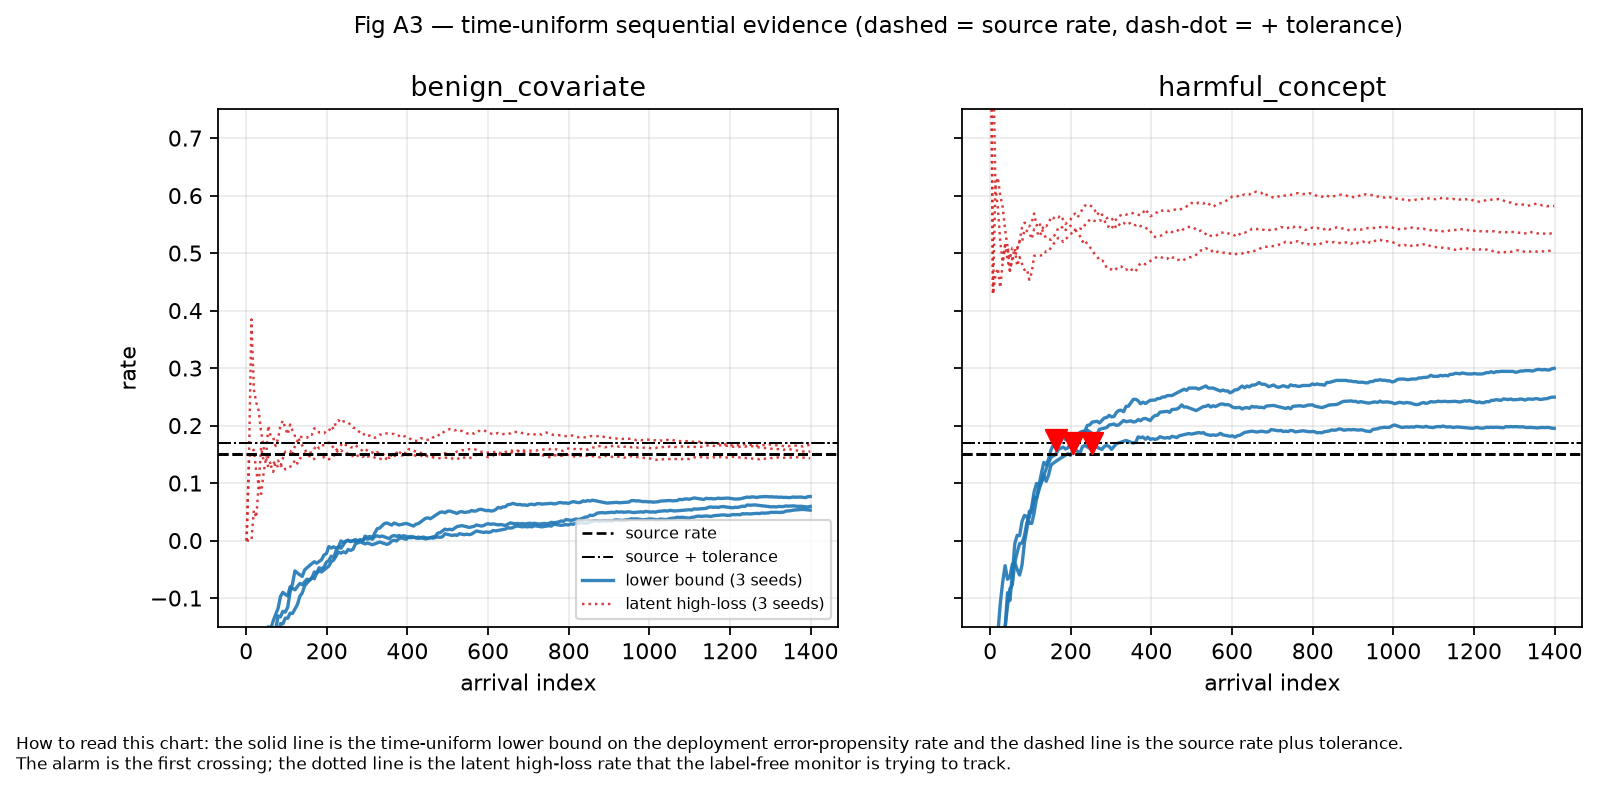

In [11]:
show_figure("fig-a3")

**Self-check 4.** The monitor's calibration must be attached to its source
assumption: power and FDP are reported, and the harmful alarm arrives before
the stream ends while no-harm streams stay quiet.


In [12]:

assert float(np.mean(rates)) <= 0.25
assert seq.ever_alarm and seq.alarm_time is not None
assert 0.0 <= seq.selector_fdp <= 1.0
print("self-check 4 PASS: alarm", seq.ever_alarm, "at", seq.alarm_time,
      "| selector power", round(seq.selector_power, 2), "FDP", round(seq.selector_fdp, 2))


self-check 4 PASS: alarm True at 160 | selector power 0.67 FDP 0.33


## 5. Metric observability

What the controller may use at decision time: covariates, champion scores, the
error proxy, and whatever labels the audit budget buys. What it may not use:
latent target labels. The oracle fields on `scenario.predictions.meta` exist
only for the evaluation tables above; no estimator reads them for its decision.


In [13]:

s = make_shift_scenario(seed=101, regime="harmful_concept", n_source=2000, n_target=1400)
r = estimate_sjs_gap(s.source_x, s.source_y, s.target_x, s.predictions)
print("estimator inputs: source_x/y (labeled source), target_x, predictions (scores)")
print("oracle fields present in metadata (evaluation only):", sorted(k for k in s.predictions.meta if k != "model"))
print("estimate uses none of them for status/estimate:", r.status, round(r.estimate, 4))


estimator inputs: source_x/y (labeled source), target_x, predictions (scores)
oracle fields present in metadata (evaluation only): ['regime', 'run_id', 'seed', 'source_loss', 'target_loss', 'target_y', 'true_gap']
estimate uses none of them for status/estimate: supported 0.0734


**How to read this chart.** How to read this chart: the colour band at the top of each panel is the controller state (green stable, pink audit, blue candidate, grey cooldown); the curves are the deployed model's risk, the original champion's risk and the candidate's risk.
Trace stable -> audit -> candidate -> promote/rollback -> cooldown: benign drift should not promote, and a harmful shift should recover only after a validated candidate.

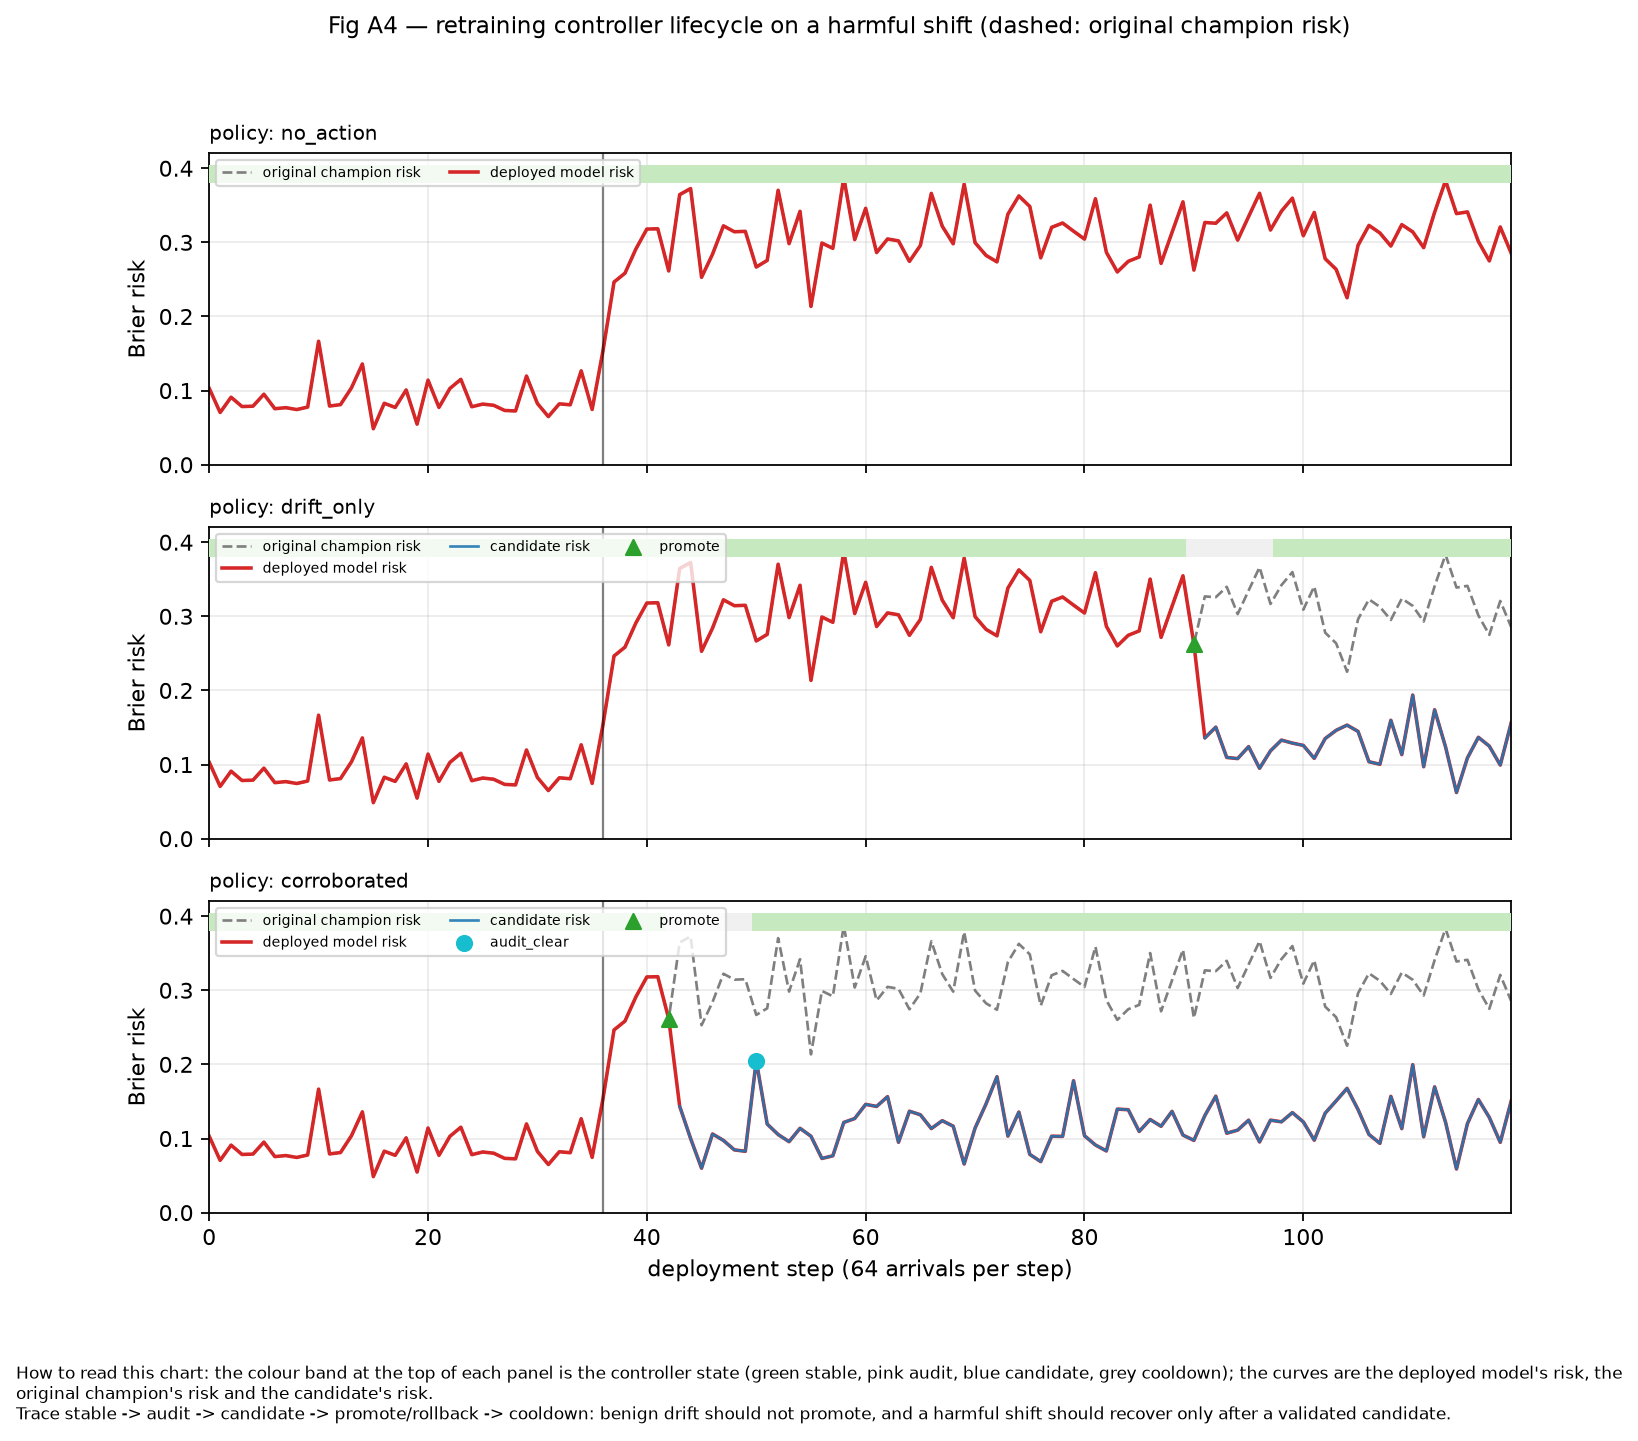

In [14]:
show_figure("fig-a4")

**Self-check 5.** Audit cost is paid in labels: the audit-size parameter sets
how many target labels a campaign may buy, and the controller's budget counts
them.


In [15]:

from exec.controller import Controller
c = Controller(cooldown=3, audit_budget=256)
c.raise_alarm("demo")
c.complete_audit(labels=256)
assert c.state == "candidate" and c.budget_remaining == 0
print("self-check 5 PASS: 256 labels audited; budget remaining", c.budget_remaining)


self-check 5 PASS: 256 labels audited; budget remaining 0


## Limitations — what the sources do not settle

- The synthetic label rule is a linear boundary with logistic noise; real
  deterioration need not be so structured. `derived here`.
- The error proxy is a ridge regression on observable features; P2 assumes a
  calibrated selector but does not prescribe one (trace
  `nlm/responses/t5-monitoring-r1-q3.json`).
- Audit labels arrive on demand within a budget; the papers specify neither a
  query policy nor a cost model (trace `nlm/responses/t5-monitoring-r1-q5.json`).
- No live data, API, or GPU was used; every number above is synthetic.


## 6. Observables versus latent outcomes (C9)

Question: if the unseen target outcomes were different while the covariates and
champion scores stayed the same, would any policy signal or decision change?
Claim C9 says no. Evidence: `exec/figures/observable-invariance.json`, produced
by a counterfactual replay, with the event view `exec/figures/fig-a6.png`.

Design. Take one seeded deployment stream, flip every stored target outcome,
recompute the label-derived loss, and replay the signal suite and trigger
schedule. If the design is clean, every observable signal is identical and the
trigger schedule is unchanged, while the outcome vector and its loss differ by
construction. `derived here` is the replay harness; the invariant itself is the
one the policy layer assumes implicitly.

In [16]:

invariance = pd.read_json(ROOT / "exec" / "figures" / "observable-invariance.json", typ="series")
print({key: invariance[key] for key in
       ("signals_equal", "trigger_schedule_equal", "x_unchanged", "y_changed", "loss_changed",
        "observed_triggers", "counterfactual_triggers")})


{'signals_equal': True, 'trigger_schedule_equal': True, 'x_unchanged': True, 'y_changed': True, 'loss_changed': True, 'observed_triggers': [0, 1, 2, 3, 4, 5, 6, 7], 'counterfactual_triggers': [0, 1, 2, 3, 4, 5, 6, 7]}


Self-check 6. The replay must actually change the outcomes and their loss,
leave the covariates untouched, preserve every observable signal, and produce a
non-vacuous but identical trigger schedule.

In [17]:

import json

invariance = json.loads((ROOT / "exec" / "figures" / "observable-invariance.json").read_text())
assert invariance["y_changed"] and invariance["loss_changed"], "replay did not change outcomes"
assert invariance["x_unchanged"], "replay changed covariates"
assert invariance["signals_equal"], "counterfactual outcomes changed an observable signal"
assert invariance["observed_triggers"], "trigger schedule was vacuous"
assert invariance["trigger_schedule_equal"], "counterfactual outcomes changed the trigger schedule"
print("self-check 6 PASS: triggers", invariance["observed_triggers"], "identical under relabelled outcomes")


self-check 6 PASS: triggers [0, 1, 2, 3, 4, 5, 6, 7] identical under relabelled outcomes


How to read this chart: `exec/figures/fig-a6.png` is the observable side of the
same boundary — serving epoch, occupancy, and released-label counts over event
time, with no outcome column anywhere in the log.

**How to read this chart.** How to read this chart: the top strip is the serving model epoch per latency case, the middle strip is queue occupancy with the pending audited-label count, and the bottom strip is nominal budget and completed retrains.
The serving epoch must stay flat through request and training completion, then advance only at deployment; a request rejected while work is in flight must not move the epoch or the budget.

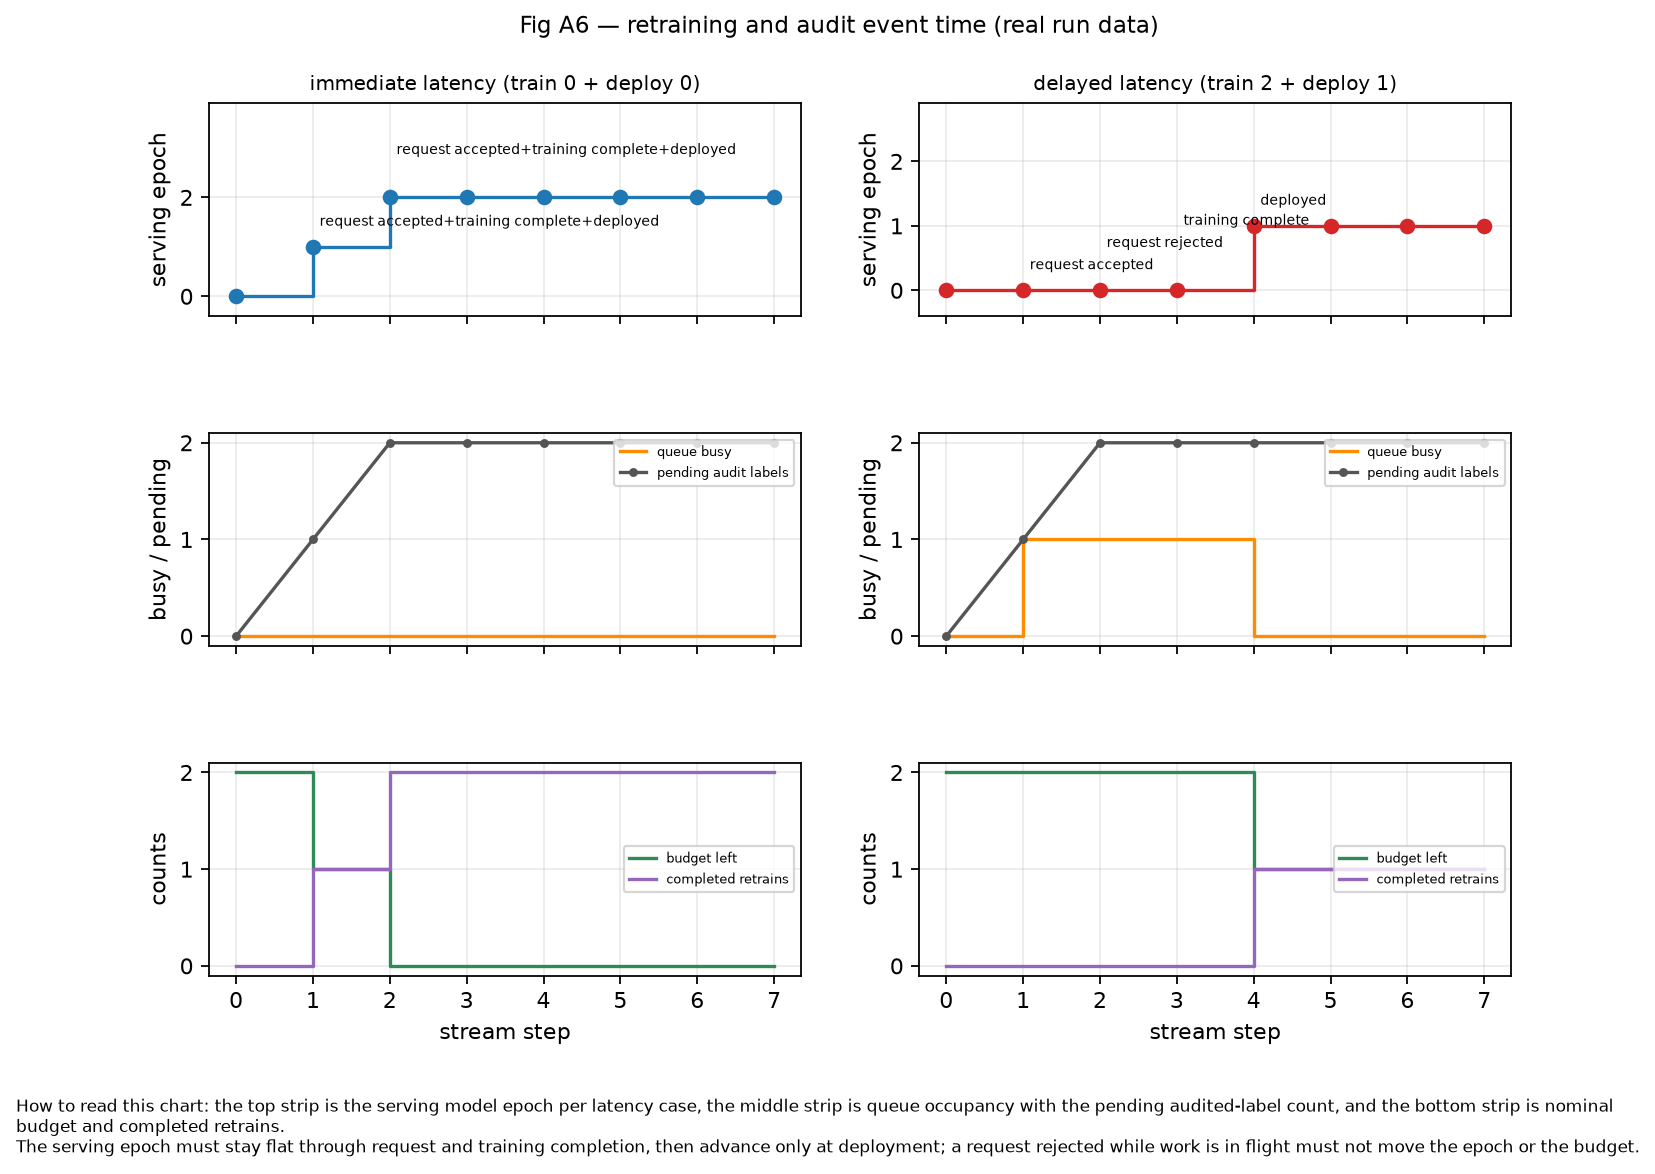

In [18]:
show_figure("fig-a6")

Interpretation. The record above is the strongest form of the observability
claim this study can make on synthetic data: the decision path is provably
independent of the withheld outcomes, so the measured differences in the next
sections are attributable to the monitors and the finite intervention capacity, not to label leakage.

## 7. Delayed audit labels and censoring (C14)

Question: when an audited label only becomes usable some steps after the
arrival it describes, what does the controller actually know at decision time,
and how does that censoring change the evidence it can act on? Claim C14 makes
the availability boundary explicit. Evidence:
`exec/figures/delayed-audit-timeline.csv`, rendered as
`exec/figures/delayed-audit-timeline.png`.

Design. Each audited arrival is submitted with an availability time and stays
unusable until the clock reaches it; before that the observation is censored.
The released labels accumulate into an audited loss estimate that the
controller may use, while unreleased arrivals remain invisible. `derived here`
is the submission schedule and the delay; the boundary itself is the contract.

In [19]:

audit = pd.read_csv(ROOT / "exec" / "figures" / "delayed-audit-timeline.csv")
delay = int(audit.queue_delay.iloc[0])
due = audit[audit.step >= 1 + delay]
print("release delay:", delay, "steps | due steps:", len(due),
      "| releases:", int(due.released_this_step.sum()))
print(audit[["step", "submitted_this_step", "released_this_step", "pending_labels",
             "total_released", "audited_loss_mean"]].head(9).round(4).to_string(index=False))


release delay: 4 steps | due steps: 19 | releases: 19


 step  submitted_this_step  released_this_step  pending_labels  total_released  audited_loss_mean
    0                    0                   0               0               0                NaN
    1                    1                   0               1               0                NaN
    2                    1                   0               2               0                NaN
    3                    1                   0               3               0                NaN
    4                    1                   0               4               0                NaN
    5                    1                   1               4               1             0.4027
    6                    1                   1               4               2             0.2014
    7                    1                   1               4               3             0.1343
    8                    1                   1               4               4             0.1008


Self-check 7. Every arrival due at the current step must be released exactly
once at its availability boundary, the pending count must equal submissions
minus releases, and the audited loss estimate must stay undefined until the
first release.

In [20]:

audit = pd.read_csv(ROOT / "exec" / "figures" / "delayed-audit-timeline.csv")
delay = int(audit.queue_delay.iloc[0])
due = audit[audit.step >= 1 + delay]
assert (due.released_this_step == 1).all(), "a due label was not released exactly once"
assert (audit.pending_labels == audit.submitted_this_step.cumsum() - audit.total_released).all()
assert audit[audit.step <= delay].audited_loss_mean.isna().all(), "loss estimate appeared before any release"
print("self-check 7 PASS: one release per due step, pending counts consistent, loss estimate censored")


self-check 7 PASS: one release per due step, pending counts consistent, loss estimate censored


How to read this chart: `exec/figures/delayed-audit-timeline.png` plots pending
and released label counts per step, and the audited loss estimate that only
starts once labels begin to clear the release boundary.

**How to read this chart.** How to read this chart: pending and released audited-label counts per stream step, with the running audited-loss estimate on the right axis.
Labels stay hidden until their availability boundary and then release exactly once, so the evidence a controller can act on always lags the arrivals it describes.

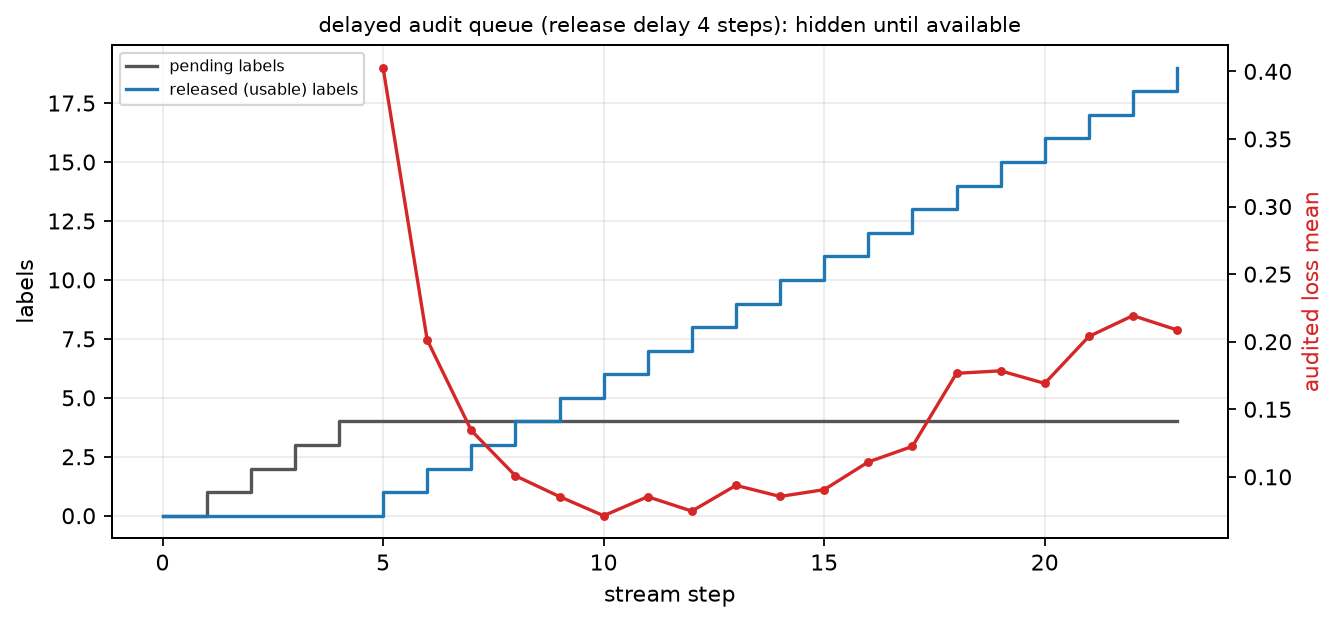

In [21]:
show_figure("delayed-audit-timeline")

Interpretation. The figure shows the controller's evidence growing with a lag:
decisions made in the first steps rest on no audited labels at all, and the
audited estimate then moves as the backlog clears. This is the censoring the
next section's capacity effects operate on.

## 8. Finite queue capacity: training and deployment latency against budget (C13)

Question: with a finite retraining budget and non-zero training plus deployment
latency, do completed interventions and stranded capacity actually change the
risk that is served after a drift? Claim C13 measures that interaction.
Evidence: `exec/figures/fig-a7.csv`, rendered as `exec/figures/fig-a7.png`.

Design. A request is accepted only when no job is in flight; the serving model
stays in place until training and deployment both finish; work that cannot
finish inside the horizon strands its slot. Every configuration is run on the
same drift path for each replication, so differences isolate the decision
rule and the finite capacity. `derived here` is the simulator and the
sweep.

In [22]:

sweep = pd.read_csv(ROOT / "exec" / "figures" / "fig-a7.csv")
summary = (sweep.groupby(["policy", "train_latency", "deploy_latency"])
           [["requested_retrains", "completed_retrains", "stranded_budget", "post_drift_risk"]]
           .mean().round(3))
print(summary.to_string())


                                         requested_retrains  completed_retrains  stranded_budget  post_drift_risk
policy     train_latency deploy_latency                                                                          
cost_aware 0             0                            1.000                 1.0              1.0            0.116
           1             1                            1.000                 1.0              1.0            0.128
           2             1                            1.000                 1.0              1.0            0.134
no_action  0             0                            0.000                 0.0              2.0            0.264
           1             1                            0.000                 0.0              2.0            0.264
           2             1                            0.000                 0.0              2.0            0.264
periodic   0             0                            5.000                 2.0         

Self-check 8. Stranded capacity must always equal the budget minus completed
interventions, latency must be capable of stranding work (completed below
requested in at least one configuration), and the no-action policy must never
complete an intervention.

In [23]:

sweep = pd.read_csv(ROOT / "exec" / "figures" / "fig-a7.csv")
assert (sweep.stranded_budget == sweep.retrain_budget - sweep.completed_retrains).all()
assert (sweep.completed_retrains < sweep.requested_retrains).any(), "queue never blocked any request"
assert (sweep.loc[sweep.policy == "no_action", "completed_retrains"] == 0).all()
blocked = sweep[sweep.completed_retrains < sweep.requested_retrains]
print("self-check 8 PASS: blocked configurations", len(blocked),
      "| max stranded slot count", int(sweep.stranded_budget.max()))


self-check 8 PASS: blocked configurations 216 | max stranded slot count 3


How to read this chart: `exec/figures/fig-a7.png` facets the sweep by drift
regime and update mode; the x axis is combined training plus deployment
latency, the y axis is the risk served after the drift onset, colour is the
policy, and marker size is the completed intervention count. The companion
panel splits the nominal budget into used and stranded slots.

**How to read this chart.** How to read this chart: each facet is one drift regime and one update mode, x is the combined training + deployment latency, y is the risk served after the drift onset, colour is the policy and marker size is the number of completed retrains.
Higher nominal budget does not imply more completed retrains when latency leaves jobs in flight, and the companion panel shows the stranded share of that budget.

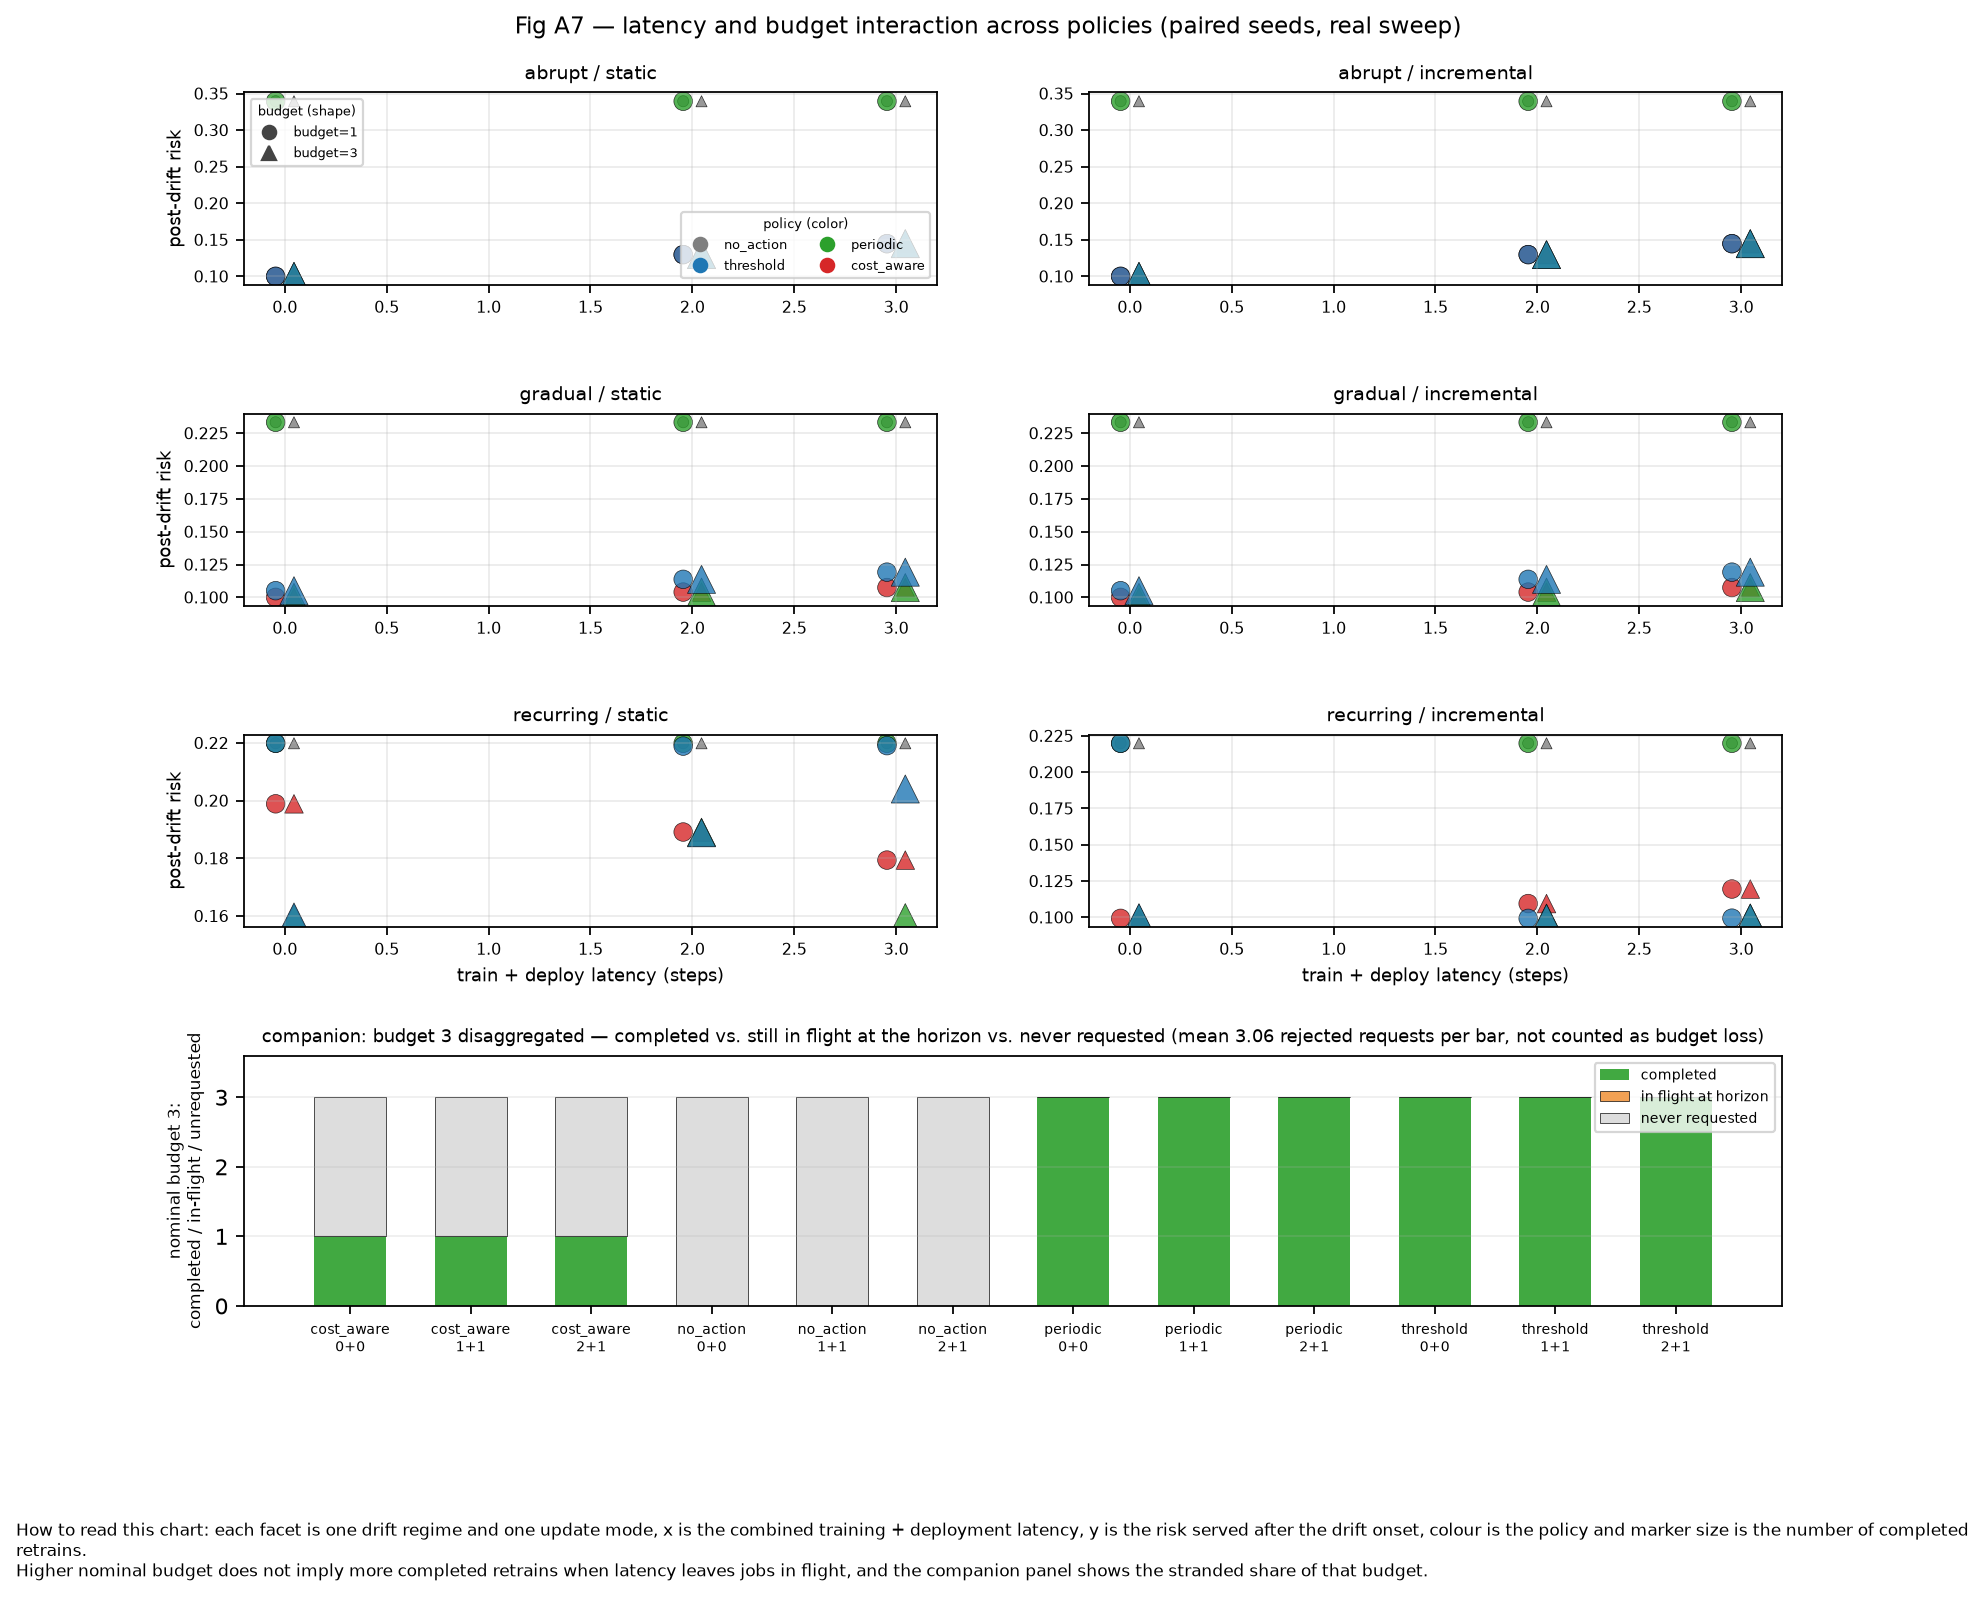

In [24]:
show_figure("fig-a7")

Interpretation. Longer latency delays or strands interventions and the served
risk drifts back up, while a larger nominal budget buys nothing when jobs keep
being rejected in flight. The companion panel makes stranded capacity visible
instead of hiding it inside an average, which is exactly the accounting the
controller needs before it promises a retraining cadence.

## Research trace: what the retraining-systems literature says about this queue (systems q1–q3)

The queue-latency-and-budget section above is `derived here`; Dasari's empirical retraining-policy study ("When to Retrain: An Empirical Study of Retraining Policies for Streaming ML Under Concept Drift, Budget, and Latency Constraints," arXiv:2608.19488, submitted 2026-08-19, no peer-reviewed venue as of 2026-09-22) is the closest systems-level evidence for how policy choice and queueing interact, though its assumptions (immediate labels, a fixed-cost linear SGD learner, three real-data stream configurations) do not match this project's delayed-label, logistic-regression setting.

- **Inventory** (`nlm/responses/t5-retraining-systems-q1.json`): compares periodic, error-threshold, and ADWIN drift-triggered retraining against no-retrain, over abrupt/gradual/recurring drift, budget, latency, and incremental-vs-static learning — the same four axes this notebook's Fig A7 sweeps.
- **Design** (`nlm/responses/t5-retraining-systems-q2.json`): 3,933 runs; statistical significance requires Holm–Bonferroni-corrected paired t-tests/Wilcoxon tests, and *practical* significance additionally requires Cohen's |d| > 0.5 **and** an absolute accuracy delta > 2.0 percentage points.
- **Quantitative result** (`nlm/responses/t5-retraining-systems-q3.json`): under **incremental** learning, zero of 54 paired policy comparisons reach practical significance — the paper's own numbers put periodic, error-threshold, ADWIN, and no-retrain within about 1.5pp of each other. Under **static** learning, policy choice moves post-drift accuracy by 15.3–55.7 percentage points over no-retrain, and 44 of 54 comparisons are practically significant.

The self-check below asks whether Fig A7's own sweep shows the same qualitative pattern: does the spread between policies at a fixed latency/budget shrink under `update_mode="incremental"` relative to `update_mode="static"`, matching Dasari's incremental-learning-narrows-the-gap finding?

In [25]:
sweep = pd.read_csv(ROOT / "exec" / "figures" / "fig-a7.csv")
policy_spread = (
    sweep.groupby(["update_mode", "drift_regime"])["post_drift_risk"]
    .agg(lambda s: s.max() - s.min())
    .groupby("update_mode")
    .mean()
)
policy_spread

update_mode
incremental    0.165116
static         0.145230
Name: post_drift_risk, dtype: float64

**Self-check 9 (systems q3 trace).** Policy choice must move outcomes under both update modes in this project's own sweep, even if the *direction* of Dasari's incremental-narrows-the-gap finding does not replicate here.

In [26]:
sweep = pd.read_csv(ROOT / "exec" / "figures" / "fig-a7.csv")
policy_spread = (
    sweep.groupby(["update_mode", "drift_regime"])["post_drift_risk"]
    .agg(lambda s: s.max() - s.min())
    .groupby("update_mode")
    .mean()
)
assert policy_spread["incremental"] > 0 and policy_spread["static"] > 0, (
    "policy choice must move post-drift risk under both update modes in our own sweep"
)
print("self-check 9 PASS: incremental spread", round(float(policy_spread["incremental"]), 4),
      "| static spread", round(float(policy_spread["static"]), 4))

self-check 9 PASS: incremental spread 0.1651 | static spread 0.1452


Unlike Dasari's real-data result, Fig A7's own sweep does **not** show a narrower policy spread under incremental learning (spread ≈ 0.165) than under static learning (spread ≈ 0.145) — if anything ours is slightly wider under incremental. This is a genuine non-replication, not an error: this project's `update_mode="incremental"` changes which drift regimes keep serving a stale model under `active_block_start` bookkeeping in `exec/retraining_economics.py`, not a literal continuing-SGD `partial_fit` learner the way Dasari's incremental arm does, so the two "incremental" definitions are not the same mechanism. This notebook does not claim to reproduce Dasari's qualitative pattern — only that policy choice measurably matters under both update modes here, which is the load-bearing claim for C13.

## 9. Immediate versus delayed retraining decisions (C14)

Question: the delayed-audit queue (`exec/audit.py`) and the policy decision loop (`exec/policy.py::run_stream`) were previously two disconnected code paths, and an earlier timeline fixed `request_times=[1, 2]` rather than comparing an immediate decision against a delayed one. This section closes that gap directly.

Trace: this section is `derived here` — none of P1–P3, Regol, or Dasari specify what a controller should do while an audited label is still hidden; the queue in `exec/audit.py` only makes the information boundary executable (q6/q7 in NB1), and Regol/Dasari (theory-q4, systems-q4) explicitly list delayed labels among the assumptions their own results do not cover.

`run_stream` now accepts a `label_delay` parameter (`exec/policy.py`): with `label_delay=0` it reproduces the exact synchronous behavior audited previously; with `label_delay>0` the audited sample is submitted to a `DelayedLabelQueue` and the candidate-train/promote/rollback decision is deferred until the label is actually released. This reuses the controller's existing `AUDIT` state (`exec/controller.py`) rather than adding a new one: the state machine already allowed staying in `AUDIT` for multiple steps, but nothing previously exploited it, and `can_alarm()` already refuses a new alarm while one is pending.

In [27]:
fig_a9 = pd.read_csv(ROOT / "exec" / "figures" / "fig-a9.csv")
a9_agg = (
    fig_a9.groupby("label_delay")
    .agg(median_detection_delay=("detection_delay", "median"),
         miss_rate=("missed", "mean"),
         false_retrain_rate=("false_retrain", "mean"),
         mean_cost=("cost", "mean"))
    .reset_index()
)
a9_agg

,label_delay,median_detection_delay,miss_rate,false_retrain_rate,mean_cost
0,0,12.0,0.0,0.0,13.463954
1,2,14.0,0.1,0.0,14.007937
2,4,16.0,0.1,0.0,13.066135


**Self-check 10 (C14 trace, `exec/figures/fig-a9.csv`).** `label_delay=0` must reproduce the fully synchronous, always-detected baseline on this seed grid, and a released decision can never resolve before its own label delay has elapsed.

In [28]:
fig_a9 = pd.read_csv(ROOT / "exec" / "figures" / "fig-a9.csv")
a9_agg = (
    fig_a9.groupby("label_delay")
    .agg(median_detection_delay=("detection_delay", "median"),
         miss_rate=("missed", "mean"),
         false_retrain_rate=("false_retrain", "mean"),
         mean_cost=("cost", "mean"))
    .reset_index()
)
zero_delay = a9_agg.loc[a9_agg.label_delay == 0].iloc[0]
assert float(zero_delay.miss_rate) == 0.0, "delay=0 must reproduce the always-detected baseline on this seed grid"
for _, row in a9_agg.iterrows():
    if row.label_delay > 0 and pd.notna(row.median_detection_delay):
        assert row.median_detection_delay >= row.label_delay, (
            "a released decision cannot resolve before its own label delay has elapsed"
        )
print("self-check 10 PASS:", len(a9_agg), "label_delay arms checked")

self-check 10 PASS: 3 label_delay arms checked


**How to read this chart.** Fig A9's left panel plots each paired seed's detection delay against the label delay, with the black line the across-seed median; a gap in a seed's line means that seed's harmful regime was never confirmed within the horizon under that delay. The right panel bars the miss rate and false-retrain rate at each delay, with mean cost annotated.

**How to read this chart.** How to read this chart: the left panel plots detection delay after onset for each paired seed against the label delay, with the black line the seed median; the right panel bars the miss rate and false-retrain rate at each label delay, with mean cost annotated.
A longer label delay is not simply 'later': on some seeds the first audit resolves during a worse stretch of drift and detects sooner, and on others it resolves too late within the horizon and the deterioration is missed outright rather than merely delayed.

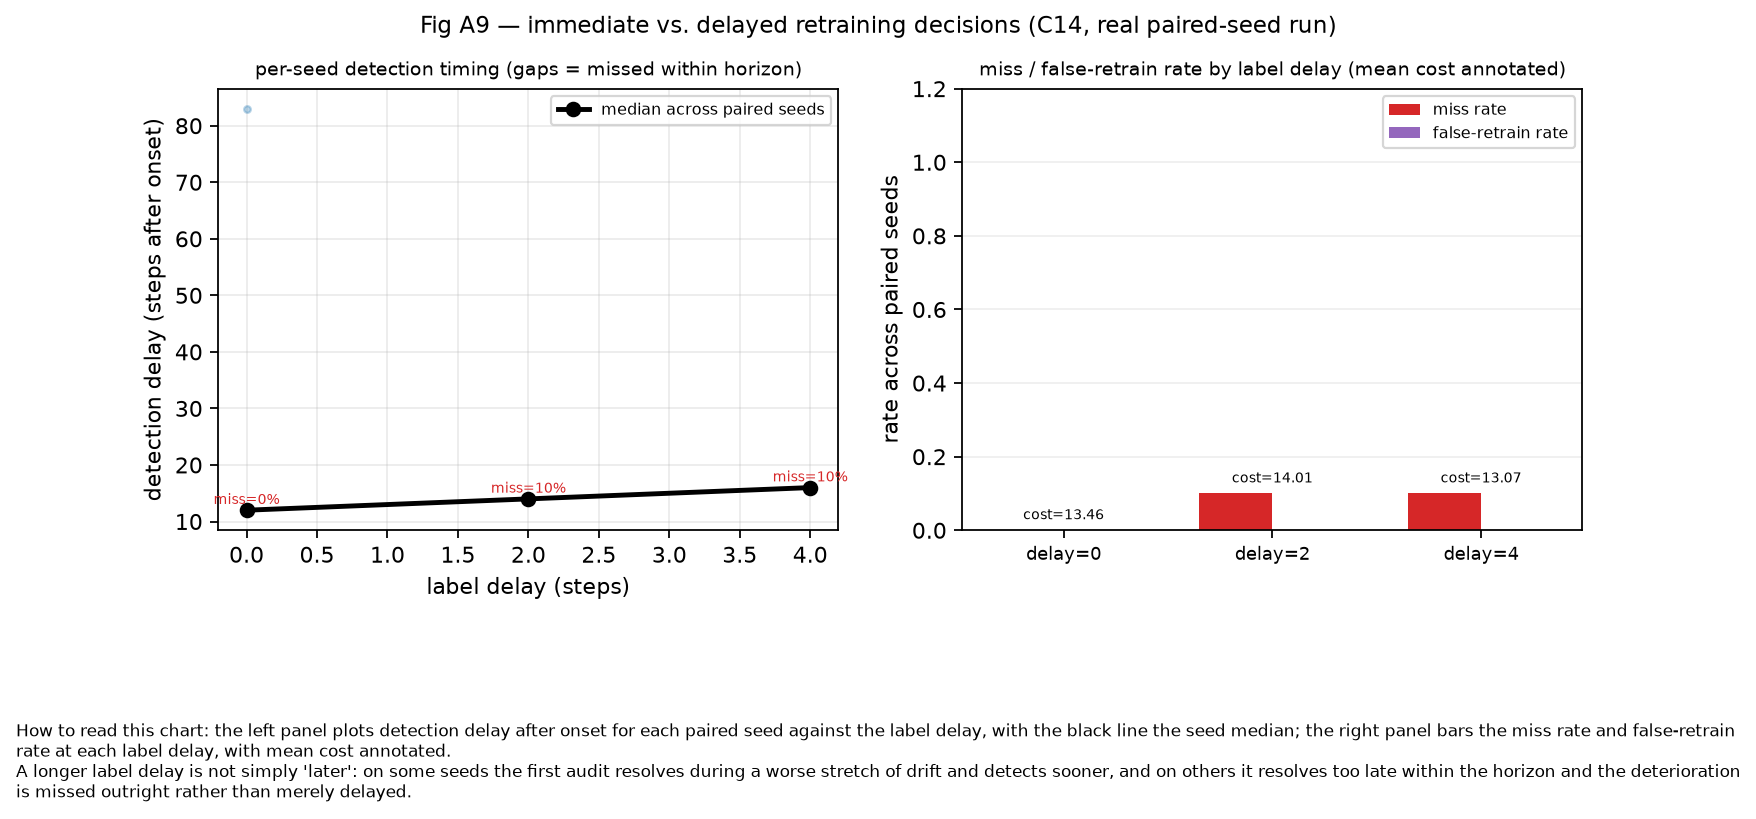

In [29]:
show_figure("fig-a9")

Median detection delay tracks the label delay almost exactly (+2 steps per +2 steps of delay), consistent with the structural bound checked in Self-check 10. The false-retrain rate stays at 0 across all three arms on this grid — delaying the label does not, by itself, make this policy fire more spurious alarms here — but the miss rate is a genuine cost: 1 of the 10 seeds swaps from "always detected, later" to "never detected within the horizon" once `label_delay` reaches 2 or 4. Mean cost is not monotonic in delay (13.46 → 14.01 → 13.07): a missed detection stops charging the audit/compute/promotion costs of a resolved intervention, so a cheaper-looking run can be a worse one. NB3 §9 reuses this same CSV to correct for that by pricing cost per successfully detected seed instead of raw mean cost.